In [1]:
import os
import time

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import utils.data as datutils
import utils.plots as plots
import utils.file as futils
import utils.corrs as corutils
import multicam.mah

import warnings
from pandas.errors import ParserWarning

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

In [2]:
dsdf_list = []
for file in sorted(os.listdir('data/gadgetx3k/G3X_progenitors/')):
    ds_file = 'data/gadgetx3k/G3X_progenitors/' + file
    ds_df = pd.read_csv(ds_file, sep=r'\s+', index_col=False)
    dsdf_list.append(ds_df)

In [3]:
ds_corr_list = []
for df in dsdf_list:
    corr = df.corr(method='spearman')
    ds_corr_list.append(corr)

In [4]:
redshift_list = pd.read_csv('data/gadgetx3k/redshift_list.txt', sep=r'\s+')
redshift_list[32:]  # DS files start at snap 32

,n,z,a
32,32,7.38900,0.1192
33,33,7.20300,0.1219
34,34,7.02600,0.1246
35,35,6.84900,0.1274
36,36,6.67500,0.1303
...,...,...,...
124,124,0.09266,0.9152
125,125,0.06872,0.9357
126,126,0.04526,0.9567
127,127,0.02239,0.9781


In [5]:
eta_delta200 = [df.loc['delta_200[4]', 'eta_200[3]'] for df in ds_corr_list]
eta_fm200 = [df.loc['fm_200[5]', 'eta_200[3]'] for df in ds_corr_list]
eta_fm2200 = [df.loc['fm2_200[6]', 'eta_200[3]'] for df in ds_corr_list]

eta_delta500 = [df.loc['delta_500[9]', 'eta_500[8]'] for df in ds_corr_list]
eta_fm500 = [df.loc['fm_500[10]', 'eta_500[8]'] for df in ds_corr_list]
eta_fm2500 = [df.loc['fm2_500[11]', 'eta_500[8]'] for df in ds_corr_list]

delta_eta200 = [df.loc['eta_200[3]', 'delta_200[4]'] for df in ds_corr_list]
delta_fm200 = [df.loc['fm_200[5]', 'delta_200[4]'] for df in ds_corr_list]
delta_fm2200 = [df.loc['fm2_200[6]', 'delta_200[4]'] for df in ds_corr_list]

delta_eta500 = [df.loc['eta_500[8]', 'delta_500[9]'] for df in ds_corr_list]
delta_fm500 = [df.loc['fm_500[10]', 'delta_500[9]'] for df in ds_corr_list]
delta_fm2500 = [df.loc['fm2_500[11]', 'delta_500[9]'] for df in ds_corr_list]

fm_eta200 = [df.loc['eta_200[3]', 'fm_200[5]'] for df in ds_corr_list]
fm_delta200 = [df.loc['delta_200[4]', 'fm_200[5]'] for df in ds_corr_list]
fm_fm2200 = [df.loc['fm2_200[6]', 'fm_200[5]'] for df in ds_corr_list]

fm_eta500 = [df.loc['eta_500[8]', 'fm_500[10]'] for df in ds_corr_list]
fm_delta500 = [df.loc['delta_500[9]', 'fm_500[10]'] for df in ds_corr_list]
fm_fm2500 = [df.loc['fm2_500[11]', 'fm_500[10]'] for df in ds_corr_list]

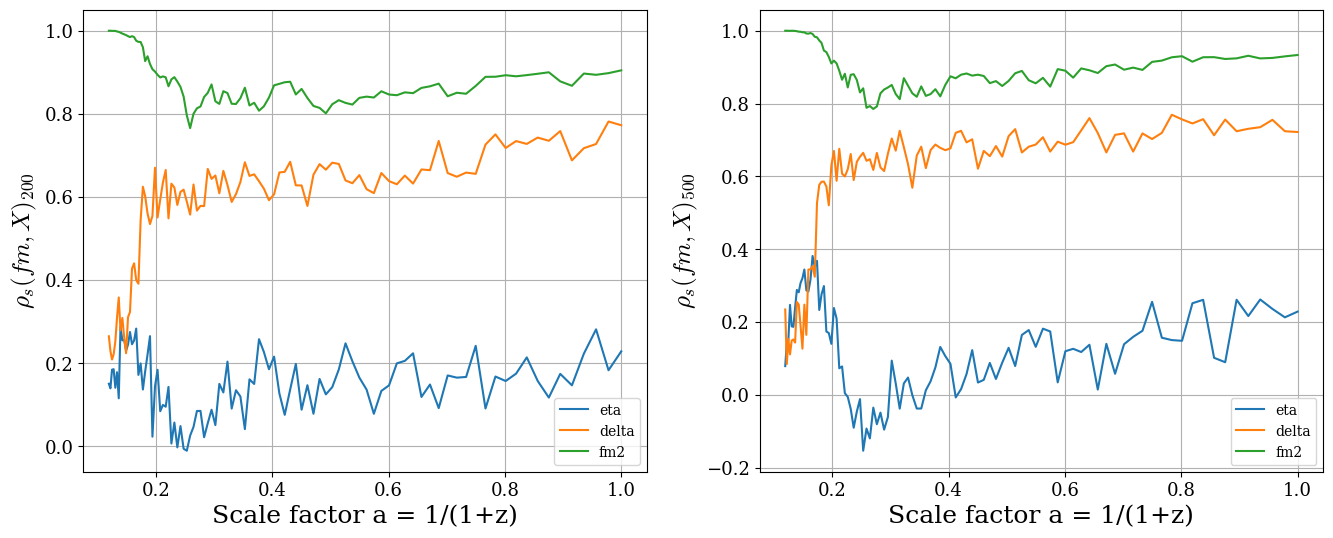

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# axs[0][0].plot(redshift_list[32:]['a'], eta_fm200, label='fm')
# axs[0][0].plot(redshift_list[32:]['a'], eta_fm2200, label='fm2')
# axs[0][0].plot(redshift_list[32:]['a'], eta_delta200, label='delta')
# axs[0][0].set_ylabel(r'$\rho_s (eta, X)_{200}$')
# axs[0][0].set_xlabel('aexp')
# axs[0][0].grid()
# axs[0][0].legend()

# axs[0][1].plot(redshift_list[32:]['a'], eta_fm500, label='fm')
# axs[0][1].plot(redshift_list[32:]['a'], eta_fm2500, label='fm2')
# axs[0][1].plot(redshift_list[32:]['a'], eta_delta500, label='delta')
# axs[0][1].set_ylabel(r'$\rho_s (eta, X)_{500}$')
# axs[0][1].set_xlabel('aexp')
# axs[0][1].grid()
# axs[0][1].legend()

# axs[1][0].plot(redshift_list[32:]['a'], delta_eta200, label='eta')
# axs[1][0].plot(redshift_list[32:]['a'], delta_fm200, label='fm')
# axs[1][0].plot(redshift_list[32:]['a'], delta_fm2200, label='fm2')
# axs[1][0].set_ylabel(r'$\rho_s (delta, X)_{200}$')
# axs[1][0].set_xlabel('aexp')
# axs[1][0].grid()
# axs[1][0].legend()

# axs[1][1].plot(redshift_list[32:]['a'], delta_eta500, label='eta')
# axs[1][1].plot(redshift_list[32:]['a'], delta_fm500, label='fm')
# axs[1][1].plot(redshift_list[32:]['a'], delta_fm2500, label='fm2')
# axs[1][1].set_ylabel(r'$\rho_s (delta, X)_{500}$')
# axs[1][1].set_xlabel('aexp')
# axs[1][1].grid()
# axs[1][1].legend()

axs[0].plot(redshift_list[32:]['a'], fm_eta200, label='eta')
axs[0].plot(redshift_list[32:]['a'], fm_delta200, label='delta')
axs[0].plot(redshift_list[32:]['a'], fm_fm2200, label='fm2')
axs[0].set_ylabel(r'$\rho_s (fm, X)_{200}$')
axs[0].set_xlabel('Scale factor a = 1/(1+z)')
axs[0].grid()
axs[0].legend()

axs[1].plot(redshift_list[32:]['a'], fm_eta500, label='eta')
axs[1].plot(redshift_list[32:]['a'], fm_delta500, label='delta')
axs[1].plot(redshift_list[32:]['a'], fm_fm2500, label='fm2')
axs[1].set_ylabel(r'$\rho_s (fm, X)_{500}$')
axs[1].set_xlabel('Scale factor a = 1/(1+z)')
axs[1].grid()
axs[1].legend()

plt.legend()
plt.savefig('plots/dsds.pdf')
plt.show()

## Heatmaps of DS(a=1) on Roan and Elena's files

In [ ]:
rds_today = 'data/gadgetx3k_20/G3X_progenitors/DS_G3X_snap_128_center-cluster_progenitors.txt'
rds_today = pd.read_csv(rds_today, sep=r'\s+')
rds_today.drop(labels=['rID[0]', 'Hid[1]', 'DS_200[2]', 'DS_500[7]'],
               axis=1, inplace=True)
rds_today = rds_today[:20]

eds_today = 'data/gadgetx3k_20/snap_125.dyn'
eds_today = pd.read_csv(eds_today, sep=r'\s+', header=1)
eds_today.drop(labels=['region'], inplace=True, axis=1)

In [ ]:
rds_corr = rds_today.corr(method='spearman')
plots.plot_corr_matrix(rds_corr)

In [ ]:
eds_corr = eds_today.corr(method='spearman')
plots.plot_corr_matrix(eds_corr)

# MAH correlations

In [34]:
mah_df_dict = futils.get_mah_all('data/gadgetx3k/AHFHaloHistory/')
indxs = [k for k in mah_df_dict.keys()]
dsdf = futils.get_ds()
dsdf = dsdf.loc[indxs]

In [35]:
ma = np.array([df['M/M0'].values for _, df in mah_df_dict.items()])
scales = mah_df_dict[1]['aexp'].values
am, common_m = multicam.mah.get_am(ma, scales=scales, min_mass_bin=0.005)

/Users/kabelo/multicam/multicam/mah.py:153: RuntimeWarning: invalid value encountered in log
  interp1d(np.log(_m_peaks), np.log(_scales), bounds_error=False, fill_value=np.nan)


In [36]:
start = time.time()
ma_ds_dict, ma_corrs, filtered_z_list = corutils.build_ma_corrs(
    mah_df_dict, dsdf)
am_ds_dict, am_corrs = corutils.build_am_corrs(
    am, masses=common_m, df0=dsdf)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)
end = time.time()
print(f'{end-start:.1f}s')

     M/M0  eta_200[3]  delta_200[4]  fm_200[5]  fm2_200[6]  eta_500[8]  \
ID                                                                       
1     1.0    1.113784      0.120344   0.191074    0.057627    0.988455   
2     1.0    1.072935      0.040830   0.112020    0.036127    1.113930   
3     1.0    0.989234      0.172955   0.328392    0.214298    1.187227   
4     1.0    1.121951      0.187624   0.219985    0.059437    1.047104   
5     1.0    1.686966      0.185922   0.231555    0.109159    1.577747   
..    ...         ...           ...        ...         ...         ...   
318   1.0    0.965212      0.024234   0.161390    0.056544    1.286893   
319   1.0    0.999232      0.028564   0.063727    0.008827    1.223898   
320   1.0    1.076578      0.022932   0.050779    0.007882    1.095860   
321   1.0    1.177087      0.112965   0.142317    0.074800    1.157092   
323   1.0    1.194351      0.092405   0.091243    0.013414    1.158983   

     delta_500[9]    fm_500[10]   fm2

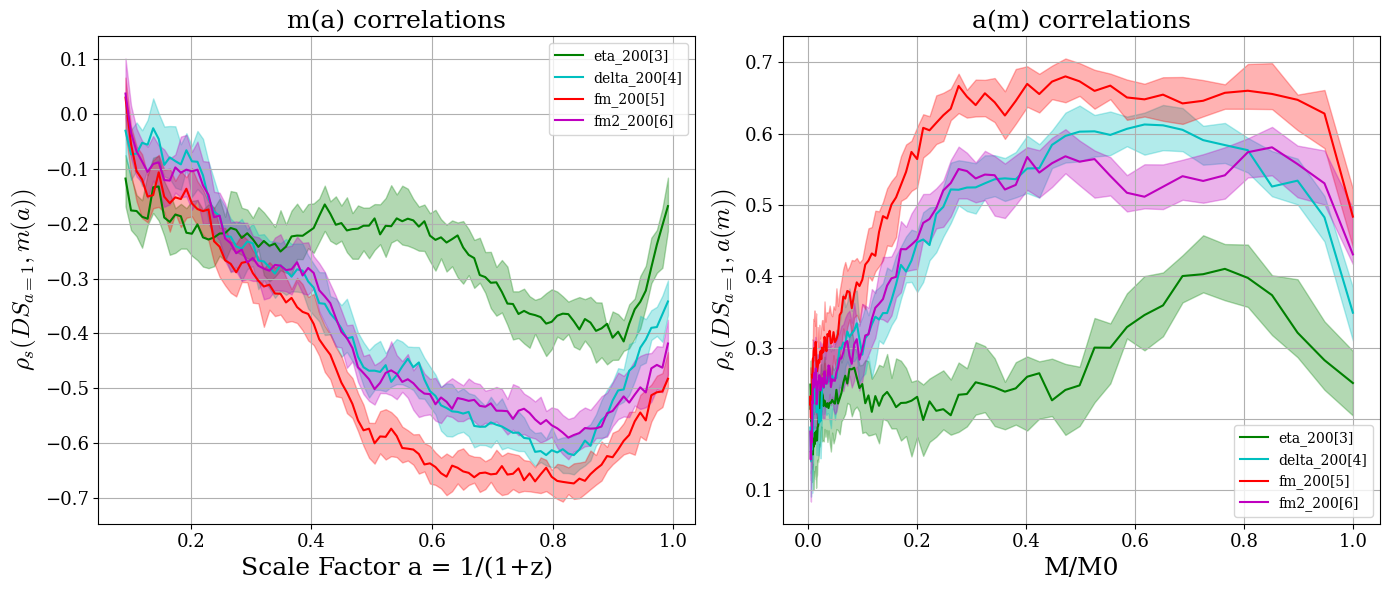

258.4s


In [39]:
start = time.time()
colors = ['g', 'c', 'r', 'm', 'b', 'y']
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, param in enumerate(dsdf.columns[:4]):

    p10, p25, p50, p75, p90 = datutils.get_percs(
        ma_ds_dict, param=param, history='M/M0')
    axs[0].set_title('m(a) correlations')
    axs[0].plot(aexp, p50, color=colors[i], label=param)
    # axs[0].fill_between(aexp, p10, p90, color=colors[i], alpha=0.2)
    axs[0].fill_between(aexp, p25, p75, color=colors[i], alpha=0.3)

    p10, p25, p50, p75, p90 = datutils.get_percs(
        am_ds_dict, param=param, history='am')
    axs[1].set_title('a(m) correlations')
    axs[1].plot(common_m, p50, color=colors[i], label=param)
    # axs[1].fill_between(common_m, p10, p90, color=colors[i], alpha=0.2)
    axs[1].fill_between(common_m, p25, p75, color=colors[i], alpha=0.3)

axs[0].set_xlabel('Scale Factor a = 1/(1+z)')
axs[0].set_ylabel(r'$\rho_s (DS_{a=1}, m(a))$')
axs[0].grid()
axs[0].legend()

axs[1].set_xlabel('M/M0')
axs[1].set_ylabel(r'$\rho_s (DS_{a=1}, a(m))$')
axs[1].grid()
axs[1].legend()
plt.tight_layout()
plt.savefig('plots/ds_mah_corrs.pdf')
plt.show()

end = time.time()
print(f'{end-start:.1f}s')